Epoch 0, Time Prediction (Transfer Learning) Loss: 13.9364, Test Loss: 4.5941
Epoch 10, Time Prediction (Transfer Learning) Loss: 6.2363, Test Loss: 2.1093
Epoch 20, Time Prediction (Transfer Learning) Loss: 4.9092, Test Loss: 0.4009


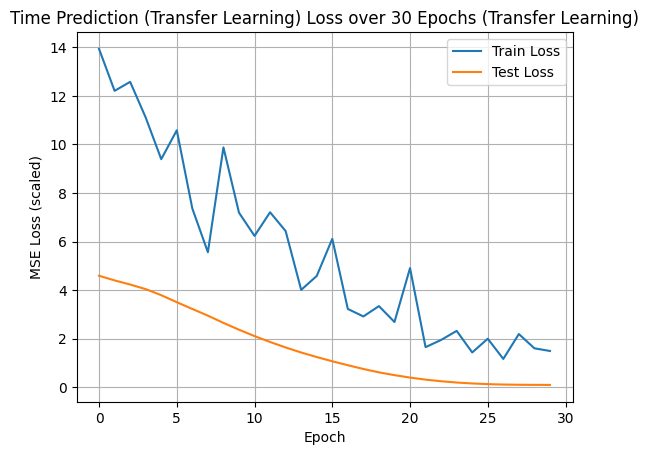

Epoch 0, Power Prediction (Transfer Learning) Loss: 0.2990, Test Loss: 1.3436
Epoch 10, Power Prediction (Transfer Learning) Loss: 0.1379, Test Loss: 0.9779
Epoch 20, Power Prediction (Transfer Learning) Loss: 0.0633, Test Loss: 0.7079


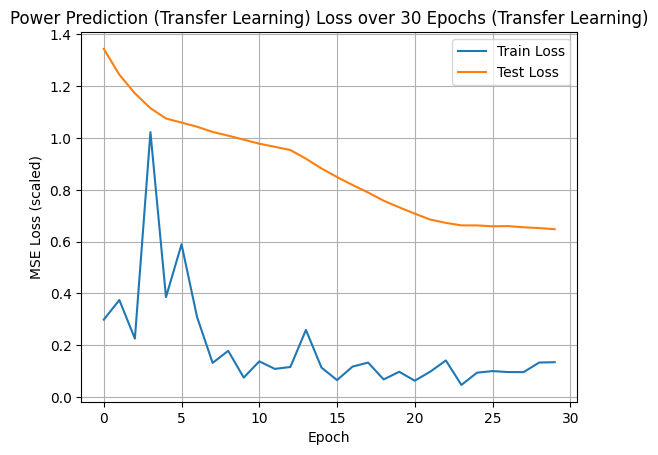


Pareto Front:
Time: 1.45s, Power: 1.68W, Mode: {'CPU_Cores': 4.0, 'CPU_Freq_MHz': 1228.0, 'GPU_Freq_MHz': 153.0}
Time: 4.58s, Power: 1.37W, Mode: {'CPU_Cores': 4.0, 'CPU_Freq_MHz': 614.0, 'GPU_Freq_MHz': 384.0}
Time: 8.16s, Power: 1.17W, Mode: {'CPU_Cores': 3.0, 'CPU_Freq_MHz': 307.0, 'GPU_Freq_MHz': 153.0}


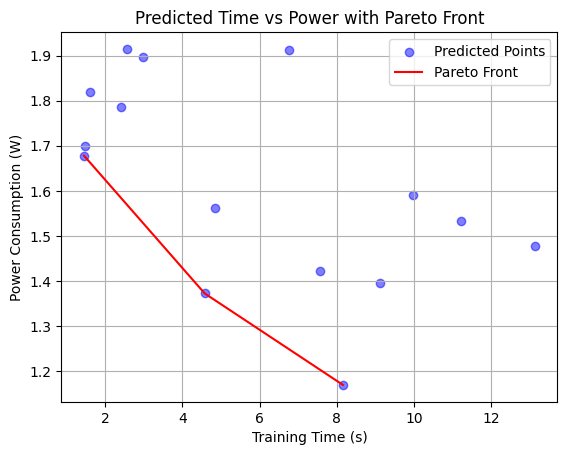

In [12]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---- Configuration ----
NEW_WORKLOAD_CSV = "power_profile_new_workload.csv"  # Path to new workload CSV
FEATURE_COLUMNS = ['CPU_Cores', 'CPU_Freq_MHz', 'GPU_Freq_MHz']
TARGET_TIME_COL = 'Avg_Time_s'
TARGET_POWER_COL = 'Avg_Total_Power_mW'
NUM_SAMPLES = 50  # Number of power modes to sample for transfer learning
EPOCHS = 50  # Number of epochs for fine-tuning

# ---- Neural Network Architecture ----
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(len(FEATURE_COLUMNS), 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

# ---- Transfer Learning Function ----
def transfer_learning(new_workload_csv, num_samples=NUM_SAMPLES, epochs=EPOCHS):
    # Load pre-trained models and scalers
    model_time = SimpleNN()
    model_power = SimpleNN()
    model_time.load_state_dict(torch.load("model_time_reference.pt"))
    model_power.load_state_dict(torch.load("model_power_reference.pt"))
    
    feature_scaler = joblib.load("feature_scaler.pkl")
    time_scaler = joblib.load("time_target_scaler.pkl")
    power_scaler = joblib.load("power_target_scaler.pkl")
    
    # Load new workload data
    df_new = pd.read_csv(new_workload_csv)
    
    # Sample a subset of power modes
    sampled_indices = np.random.choice(len(df_new), num_samples, replace=False)
    df_sampled = df_new.iloc[sampled_indices]
    
    # Prepare features and targets
    X_new = df_sampled[FEATURE_COLUMNS].values
    y_time_new = df_sampled[TARGET_TIME_COL].values.reshape(-1, 1)
    y_power_new = (df_sampled[TARGET_POWER_COL] / 1000.0).values.reshape(-1, 1)  # Convert mW to W
    
    # Split into train/test
    X_train_new, X_test_new, y_time_train_new, y_time_test_new, y_power_train_new, y_power_test_new = train_test_split(
        X_new, y_time_new, y_power_new, test_size=0.2, random_state=42)
    
    # Scale data using pre-fitted scalers
    X_train_new_scaled = feature_scaler.transform(X_train_new)
    X_test_new_scaled = feature_scaler.transform(X_test_new)
    y_time_train_new_scaled = time_scaler.transform(y_time_train_new)
    y_time_test_new_scaled = time_scaler.transform(y_time_test_new)
    y_power_train_new_scaled = power_scaler.transform(y_power_train_new)
    y_power_test_new_scaled = power_scaler.transform(y_power_test_new)
    
    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_new_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_new_scaled, dtype=torch.float32)
    y_time_train_tensor = torch.tensor(y_time_train_new_scaled, dtype=torch.float32)
    y_time_test_tensor = torch.tensor(y_time_test_new_scaled, dtype=torch.float32)
    y_power_train_tensor = torch.tensor(y_power_train_new_scaled, dtype=torch.float32)
    y_power_test_tensor = torch.tensor(y_power_test_new_scaled, dtype=torch.float32)
    
    # Fine-tune models
    def fine_tune_model(model, optimizer, X_tr, y_tr, X_te, y_te, epochs, title):
        criterion = nn.MSELoss()
        train_losses, test_losses = [], []
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(X_tr)
            loss = criterion(out, y_tr)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            
            model.eval()
            with torch.no_grad():
                test_loss = criterion(model(X_te), y_te).item()
                test_losses.append(test_loss)
            
            if epoch % 10 == 0:
                print(f'Epoch {epoch}, {title} Loss: {loss.item():.4f}, Test Loss: {test_loss:.4f}')
        
        # Plot losses
        plt.figure()
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.title(f"{title} Loss over {epochs} Epochs (Transfer Learning)")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss (scaled)")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        return model
    
    # Fine-tune time model
    opt_time = optim.Adam(model_time.parameters(), lr=0.001)  # Lower learning rate for fine-tuning
    model_time = fine_tune_model(
        model_time, opt_time,
        X_train_tensor, y_time_train_tensor,
        X_test_tensor, y_time_test_tensor,
        epochs, "Time Prediction (Transfer Learning)"
    )
    
    # Fine-tune power model
    opt_power = optim.Adam(model_power.parameters(), lr=0.001)
    model_power = fine_tune_model(
        model_power, opt_power,
        X_train_tensor, y_power_train_tensor,
        X_test_tensor, y_power_test_tensor,
        epochs, "Power Prediction (Transfer Learning)"
    )
    
    # Save fine-tuned models
    torch.save(model_time.state_dict(), "model_time_transferred.pt")
    torch.save(model_power.state_dict(), "model_power_transferred.pt")
    
    return model_time, model_power, feature_scaler, time_scaler, power_scaler

# ---- Prediction and Pareto Front Generation ----
def predict_and_generate_pareto(model_time, model_power, feature_scaler, time_scaler, power_scaler, power_modes_df):
    # Prepare features
    X_all = power_modes_df[FEATURE_COLUMNS].values
    X_all_scaled = feature_scaler.transform(X_all)
    X_all_tensor = torch.tensor(X_all_scaled, dtype=torch.float32)
    
    # Predict
    model_time.eval()
    model_power.eval()
    with torch.no_grad():
        time_preds_scaled = model_time(X_all_tensor).numpy()
        power_preds_scaled = model_power(X_all_tensor).numpy()
    
    # Inverse transform predictions
    time_preds = time_scaler.inverse_transform(time_preds_scaled).flatten()
    power_preds = power_scaler.inverse_transform(power_preds_scaled).flatten()
    
    # Generate Pareto front
    points = list(zip(time_preds, power_preds, range(len(power_modes_df))))
    points.sort()  # Sort by time
    
    pareto_front = []
    min_power = float('inf')
    
    for time, power, idx in points:
        if power <= min_power:
            pareto_front.append({
                'time': time,
                'power': power,
                'mode': power_modes_df.iloc[idx][FEATURE_COLUMNS].to_dict()
            })
            min_power = power
    
    return time_preds, power_preds, pareto_front

# ---- Example Usage ----
if __name__ == "__main__":
    # Perform transfer learning
    NEW_WORKLOAD_CSV = "svm.csv"  # Path to new workload CSV
    NUM_SAMPLES =10
    EPOCHS = 30
    model_time_trans, model_power_trans, feature_scaler, time_scaler, power_scaler = transfer_learning(
        NEW_WORKLOAD_CSV, num_samples=NUM_SAMPLES, epochs=EPOCHS
    )
    
    # Load all power modes for prediction (could be the new workload CSV or a separate power modes CSV)
    power_modes_df = pd.read_csv(NEW_WORKLOAD_CSV)
    
    # Predict and generate Pareto front
    time_preds, power_preds, pareto_front = predict_and_generate_pareto(
        model_time_trans, model_power_trans, feature_scaler, time_scaler, power_scaler, power_modes_df
    )
    
    # Print Pareto front
    print("\nPareto Front:")
    for point in pareto_front:
        print(f"Time: {point['time']:.2f}s, Power: {point['power']:.2f}W, Mode: {point['mode']}")
    
    # Optional: Plot predictions
    plt.figure()
    plt.scatter(time_preds, power_preds, c='blue', alpha=0.5, label='Predicted Points')
    pareto_times = [p['time'] for p in pareto_front]
    pareto_powers = [p['power'] for p in pareto_front]
    plt.plot(pareto_times, pareto_powers, 'r-', label='Pareto Front')
    plt.xlabel('Training Time (s)')
    plt.ylabel('Power Consumption (W)')
    plt.title('Predicted Time vs Power with Pareto Front')
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import uuid

# Neural Network Model for Power and Time Prediction
class PowerTrainNN(nn.Module):
    def __init__(self, input_size=4):
        super(PowerTrainNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.layer2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.4)
        self.layer3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.dropout1(x)
        x = self.relu2(self.layer2(x))
        x = self.dropout2(x)
        x = self.relu3(self.layer3(x))
        x = self.layer4(x)
        return x

# Function to prepare data
def prepare_data(power_modes, times, powers, test_size=0.1):
    # Input features: CPU cores, CPU freq, GPU freq, Memory freq
    X = np.array([[pm['cpu_cores'], pm['cpu_freq'], pm['gpu_freq'], pm['mem_freq']] 
                  for pm in power_modes])
    y_time = np.array(times)
    y_power = np.array(powers)
    
    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split data
    X_train, X_test, y_time_train, y_time_test = train_test_split(
        X_scaled, y_time, test_size=test_size, random_state=42)
    X_train, X_test, y_power_train, y_power_test = train_test_split(
        X_scaled, y_power, test_size=test_size, random_state=42)
    
    return (X_train, X_test, y_time_train, y_time_test, 
            y_power_train, y_power_test, scaler)

# Function to train NN model
def train_model(model, X_train, y_train, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
    
    return model

# Transfer Learning Function
def transfer_learning(reference_model_time, reference_model_power, 
                     new_power_modes, new_times, new_powers, 
                     num_samples=50):
    # Prepare new workload data
    indices = np.random.choice(len(new_power_modes), num_samples, replace=False)
    sampled_modes = [new_power_modes[i] for i in indices]
    sampled_times = new_times[indices]
    sampled_powers = new_powers[indices]
    
    (X_train, X_test, y_time_train, y_time_test, 
     y_power_train, y_power_test, scaler) = prepare_data(
        sampled_modes, sampled_times, sampled_powers)
    
    # Initialize new models with pre-trained weights
    new_model_time = PowerTrainNN()
    new_model_power = PowerTrainNN()
    
    # Copy weights from reference models
    new_model_time.load_state_dict(reference_model_time.state_dict())
    new_model_power.load_state_dict(reference_model_power.state_dict())
    
    # Fine-tune models
    new_model_time = train_model(new_model_time, X_train, y_time_train)
    new_model_power = train_model(new_model_power, X_train, y_power_train)
    
    return new_model_time, new_model_power, scaler

# Function to predict time and power
def predict(model_time, model_power, power_modes, scaler):
    X = np.array([[pm['cpu_cores'], pm['cpu_freq'], pm['gpu_freq'], pm['mem_freq']] 
                  for pm in power_modes])
    X_scaled = scaler.transform(X)
    X_tensor = torch.FloatTensor(X_scaled)
    
    model_time.eval()
    model_power.eval()
    
    with torch.no_grad():
        time_preds = model_time(X_tensor).numpy().flatten()
        power_preds = model_power(X_tensor).numpy().flatten()
    
    return time_preds, power_preds

# Function to generate Pareto front
def generate_pareto_front(time_preds, power_preds, power_modes):
    points = list(zip(time_preds, power_preds, power_modes))
    points.sort()  # Sort by time
    
    pareto_front = []
    min_power = float('inf')
    
    for time, power, mode in points:
        if power <= min_power:
            pareto_front.append({'time': time, 'power': power, 'mode': mode})
            min_power = power
    
    return pareto_front

# Example usage
if __name__ == "__main__":
    # Sample data structure for power modes
    reference_power_modes = [
        {'cpu_cores': 12, 'cpu_freq': 2200, 'gpu_freq': 1300, 'mem_freq': 3200},
        # ... more power modes
    ]
    reference_times = np.random.rand(len(reference_power_modes)) * 100
    reference_powers = np.random.rand(len(reference_power_modes)) * 60
    
    new_power_modes = [
        {'cpu_cores': 10, 'cpu_freq': 2000, 'gpu_freq': 1200, 'mem_freq': 3000},
        # ... more power modes
    ]
    new_times = np.random.rand(len(new_power_modes)) * 100
    new_powers = np.random.rand(len(new_power_modes)) * 60
    
    # Prepare reference data
    (X_train_ref, X_test_ref, y_time_train_ref, y_time_test_ref, 
     y_power_train_ref, y_power_test_ref, scaler_ref) = prepare_data( 
        reference_power_modes, reference_times, reference_powers)
    
    # Train reference models
    reference_model_time = PowerTrainNN()
    reference_model_power = PowerTrainNN()
    
    reference_model_time = train_model(
        reference_model_time, X_train_ref, y_time_train_ref)
    reference_model_power = train_model(
        reference_model_power, X_train_ref, y_power_train_ref)
    
    # Transfer learning to new workload
    new_model_time, new_model_power, new_scaler = transfer_learning(
        reference_model_time, reference_model_power,
        new_power_modes, new_times, new_powers)
    
    # Make predictions
    time_preds, power_preds = predict(
        new_model_time, new_model_power, new_power_modes, new_scaler)
    
    # Generate Pareto front
    pareto_front = generate_pareto_front(time_preds, power_preds, new_power_modes)
    
    print("Pareto Front:")
    for point in pareto_front:
        print(f"Time: {point['time']:.2f}s, Power: {point['power']:.2f}W, "
              f"Mode: {point['mode']}")

ValueError: With n_samples=1, test_size=0.1 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.